# Predictive Maintenance Data Preprocessing

This notebook prepares the predictive maintenance dataset for machine learning experiments.

The preprocessing workflow includes:

- feature selection

- removal of target leakage

- categorical encoding

- train-test splitting

- dataset preparation for model training

# Dataset Loading

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()

df = pd.read_csv('predictive_maintenance.csv')

df.head()

ModuleNotFoundError: No module named 'google'

# Feature Selection and Removal

Certain columns were removed from the dataset because they were either:

- unique identifiers with no predictive value

- sources of target leakage

- unsuitable for model training

In [2]:
df_clean = df.drop(columns=['UDI', 'Product ID', 'Failure Type'])

df_clean.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


## Target Leakage Considerations

The 'Failure Type' column was removed during preprocessing because it directly indicates whether a machine failure occurred.

Including this feature would allow machine learning models to indirectly access target information during training, leading to unrealistic performance results.

# Encoding Categorical Variables

Machine learning algorithms require numerical inputs.

The categorical 'Type' feature was therefore transformed using one-hot encoding.

In [3]:
df_clean = pd.get_dummies(df_clean, columns=['Type'])

df_clean.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,False,True
1,298.2,308.7,1408,46.3,3,0,False,True,False
2,298.1,308.5,1498,49.4,5,0,False,True,False
3,298.2,308.6,1433,39.5,7,0,False,True,False
4,298.2,308.7,1408,40.0,9,0,False,True,False


In [6]:
df_clean = df_clean.astype(int, errors='ignore')

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Air temperature [K]      10000 non-null  int64
 1   Process temperature [K]  10000 non-null  int64
 2   Rotational speed [rpm]   10000 non-null  int64
 3   Torque [Nm]              10000 non-null  int64
 4   Tool wear [min]          10000 non-null  int64
 5   Target                   10000 non-null  int64
 6   Type_H                   10000 non-null  int64
 7   Type_L                   10000 non-null  int64
 8   Type_M                   10000 non-null  int64
dtypes: int64(9)
memory usage: 703.3 KB


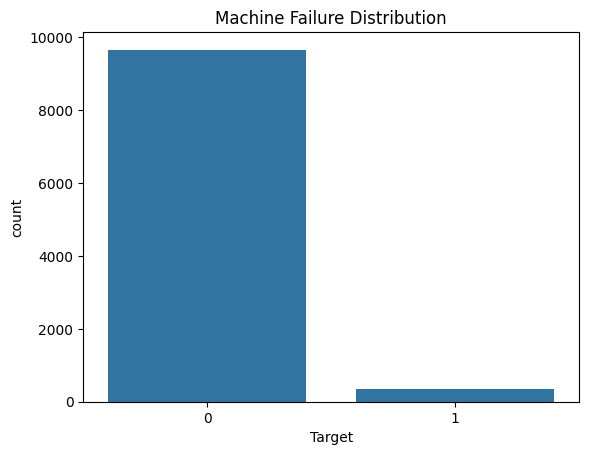

In [5]:
sns.countplot(x='Target', data=df)

plt.title('Machine Failure Distribution')

plt.show()

# Train-Test Split

The dataset was divided into training and testing subsets using an 80/20 split.

Stratified sampling was used to preserve the original class distribution due to the significant imbalance between failure and non-failure observations.

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X = df_clean.drop('Target', axis=1)

y = df_clean['Target']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
print(X_train.shape)
print(X_test.shape)

(8000, 8)
(2000, 8)


In [11]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Target
0    0.966125
1    0.033875
Name: proportion, dtype: float64
Target
0    0.966
1    0.034
Name: proportion, dtype: float64


# Feature Scaling
